<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/JS05/JS05_Tugas_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Buatlah model klasfikasi Multinomial Naive Bayes dengan ketentuan,

- Menggunakan data spam.csv

- Fitur CountVectorizer dengan mengaktifkan stop_words

- Evaluasi hasilnya

Langkah 1: Load Data

In [1]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


Langkah 2: Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Langkah 3: Membaca Dataset

In [8]:
df = pd.read_csv('spam.csv', encoding='latin-1') # spesifiksi encoding diperlukan karena data tidak menggunakan UTF-8

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Langkah 4: Drop Kolom yang tidak ada isinya

In [9]:
	# Drop 3 kolom terakhir dengan fungsi iloc
	df = df.drop(df.iloc[:,2:], axis=1)

	# Cek data
	df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Langkah 5: Mengganti Nama

In [18]:
df = df.rename(columns={'v1': 'Labels', 'v2': 'SMS'})
df.head()

,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Langkah 6: Mengecek Jumlah Data Tiap Kelas

In [17]:
	# Cek Jumlah Data Per Kelas
	print(df['Labels'].value_counts())
	print('\n')

	# Cek Kelengkapan Data
	print(df.info())
	print('\n')

	# Cek Statistik Deskriptif
	print(df.describe())

Labels
ham     4825
spam     747
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


       Labels                     SMS
count    5572                    5572
unique      2                    5169
top       ham  Sorry, I'll call later
freq     4825                      30


Langkah 7: Memisahkan Fitur dan Label

In [20]:
X = df["SMS"]
y = df["Labels"]

Langkah 8: Membagi Data Train dan Data Test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Langkah 9: Membuat CountVectorizer dengan stop_words

In [23]:
vectorizer = CountVectorizer(stop_words="english")

Langkah 10: Mengubah teks menjadi fitur numerik

In [24]:
X_train_count = vectorizer.fit_transform(X_train)
X_test_count = vectorizer.transform(X_test)

print("\nUkuran data training:", X_train_count.shape)
print("Ukuran data testing :", X_test_count.shape)


Ukuran data training: (4457, 7472)
Ukuran data testing : (1115, 7472)


Langkah 11: Membuat model Multinomial Naive Bayes

In [25]:
model = MultinomialNB()

Langkah 12: Training model

In [26]:
model.fit(X_train_count, y_train)

MultinomialNB()

Langkah 13: Prediksi data testing

In [27]:
y_pred = model.predict(X_test_count)

Langkah 14: Evaluasi akurasi

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("\n=== HASIL EVALUASI ===")
print("Akurasi: {:.2f}%".format(accuracy * 100))


=== HASIL EVALUASI ===
Akurasi: 98.39%


Langkah 15: Confusion Matrix


Confusion Matrix:
[[959   6]
 [ 12 138]]


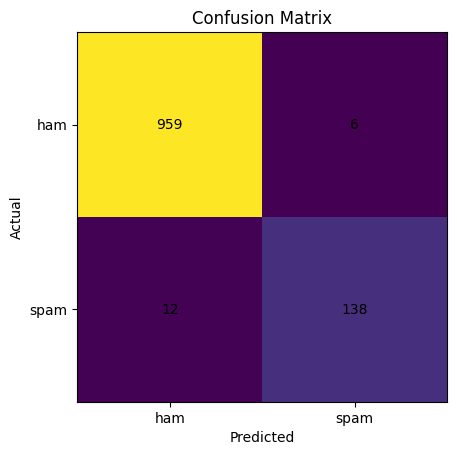

In [29]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["ham", "spam"])
plt.yticks([0, 1], ["ham", "spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

Langkah 16: Classification Report

In [30]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.96      0.92      0.94       150

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



Buatlah model klasfikasi Multinomial Naive Bayes dengan ketentuan,
- Menggunakan data spam.csv
- Fitur TF-IDF dengan mengaktifkan stop_words
- Evaluasi hasilnya dan bandingkan dengan hasil pada Tugas no 2.
- Berikan kesimpulan fitur mana yang terbaik pada kasus data spam.csv

Langkah 1: Import Library TF-IDF


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

Langkah 2: Membuat fitur TF-IDF

In [32]:
tfidf = TfidfVectorizer(stop_words='english')

Langkah 3: Mengubah teks menjadi fitur TF-IDF

In [33]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Ukuran data training:", X_train_tfidf.shape)
print("Ukuran data testing :", X_test_tfidf.shape)

Ukuran data training: (4457, 7472)
Ukuran data testing : (1115, 7472)


Langkah 4: Membuat model Multinomial Naive Bayes

In [35]:
model_tfidf = MultinomialNB()

Langkah 5: Training Model

In [36]:
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

Langkah 6: Melakukan Prediksi

In [37]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

Langkah 7: Evaluasi Akurasi

In [43]:
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("\n=== HASIL EVALUASI ===")
print("Akurasi TF-IDF: {:.2f}%".format(accuracy_tfidf * 100))


=== HASIL EVALUASI ===
Akurasi TF-IDF: 96.68%


Langkah 8: Confusion Matrix

In [41]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

print("Confusion Matrix:")
print(cm_tfidf)

Confusion Matrix:
[[965   0]
 [ 37 113]]


Langkah 9: Classification Report

In [42]:
print("Classification Report:")
print(classification_report(y_test, y_pred_tfidf))

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



Berdasarkan hasil evaluasi, model Multinomial Naive Bayes dengan fitur CountVectorizer memperoleh akurasi sebesar 98,39%, sedangkan model dengan fitur TF-IDF memperoleh akurasi sebesar 96,68%. Terdapat selisih akurasi sebesar 1,71%, sehingga pada kasus klasifikasi data spam.csv, fitur CountVectorizer menghasilkan akurasi yang lebih tinggi dibandingkan fitur TF-IDF.

Dengan demikian, berdasarkan nilai akurasi pada pengujian ini, CountVectorizer merupakan fitur yang memberikan hasil lebih baik untuk klasifikasi spam menggunakan Multinomial Naive Bayes. Meskipun TF-IDF juga memberikan hasil yang cukup tinggi, performanya pada dataset ini masih berada di bawah CountVectorizer.
